<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/A06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from google.colab import files
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [2]:
dt = files.upload()

Saving brain_tumor_dataset.csv to brain_tumor_dataset (6).csv


In [3]:
df = pd.read_csv('brain_tumor_dataset (1).csv')

DEBIDO A QUE TRABAJO DESDE COLAB, IMPORTARE LOS DATOS MEDIANTE LA API DE KAGGEL

# **EDA**


In [4]:
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

array([[<Axes: title={'center': 'Patient_ID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Tumor_Size'}>,
        <Axes: title={'center': 'Survival_Rate'}>],
       [<Axes: title={'center': 'Tumor_Growth_Rate'}>, <Axes: >]],
      dtype=object)

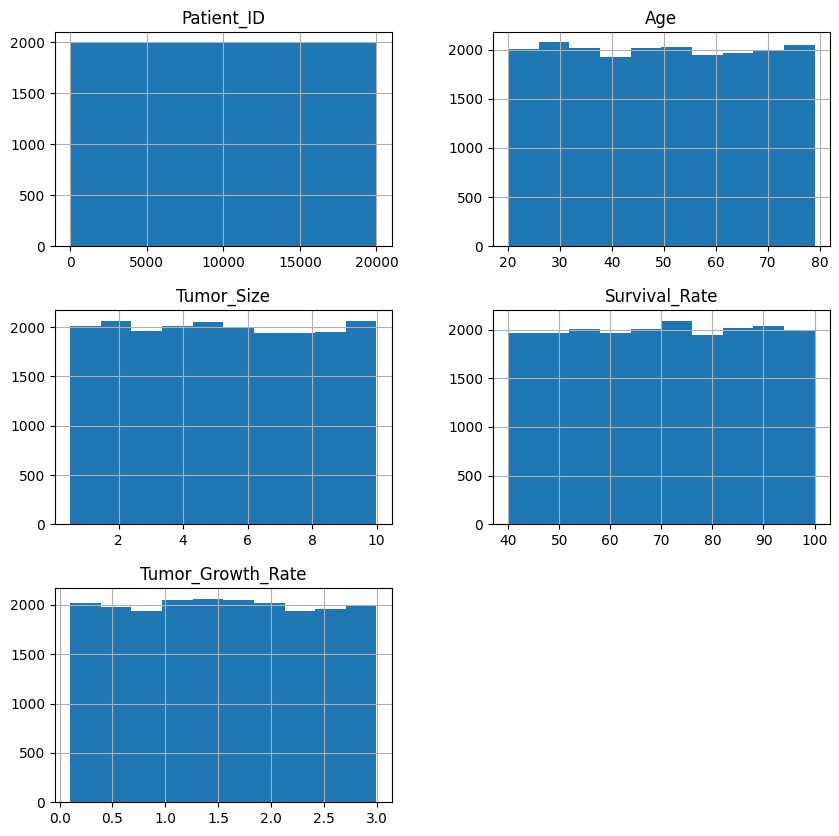

In [6]:
df.hist(figsize=(10,10))

In [7]:
Quimio = sum(((df["Chemotherapy"] == "Yes") & (df['Surgery_Performed'] == "Yes") & (df['Radiation_Treatment'] == "Yes")).astype(int))

print(f'Quimio: {Quimio}')

Quimio: 2590


# ***ING.CARACTERES***

In [8]:
df['Tumor_Type'] = df['Tumor_Type'].replace({'Glioblastoma': 1, 'Normal': 0})

In [9]:
numericos = ['Age',"Tumor_Size","Survival_Rate","Tumor_Growth_Rate"]
categoricos = ['Gender','Location',	'Histology','Radiation_Treatment'	,'Surgery_Performed'	,'Chemotherapy',	'Family_History',	'MRI_Result',	'Follow_Up_Required']
ordinales = ["Stage"]
target = ["Tumor_Type"]


Crear un modelo SVC con kernel lineal y optimizar el promedio del AUC en kfolds=10.



In [10]:
categories = ['I','II','III','IV']


In [11]:
X = df[numericos+categoricos+ordinales]
y = df[target]

In [12]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first')
ord_transformer = OrdinalEncoder(categories=[categories])
model = SVC(probability = True, kernel = "linear", random_state=42, C=1)

# ***APLICAMOS EL PIPELINE***

In [13]:
preprocesor = ColumnTransformer(transformers=[('num',num_transformer,numericos), ('cat', cat_transformer, categoricos), ('ord', ord_transformer, ordinales)])
pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', model)])

In [ ]:
pipeline.fit(X,y.values.ravel())

CROSS VALIDATION

In [ ]:
scores = pd.DataFrame(cross_val_score(pipeline, X, y, cv=10, scoring='accuracy'), columns=['auc'])
scores.mean()

# ***OPTIMIZACIÓN BAYESIANA***

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import matplotlib.pyplot as plt


In [ ]:
def f(x):
  model = SVC(probability = True, kernel = "linear", random_state=42, C=x)
  pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', model)])
  scores = cross_val_score(pipeline, X, y.values.ravel(), cv=10, scoring='f1')
  return scores.mean()

In [ ]:
f(10)

In [ ]:
n_initial = [.001,10]
X_hist = np.zeros((3, 1))
y_hist = np.zeros((3, 1))

In [ ]:
print(y_hist)
print(X_hist)


In [ ]:
kernel = 1 * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=10)

In [ ]:
for i in range(7):

  gpr.fit(X_hist, y_hist)

  #¿Que Y predecimos?
  x_pred = np.linspace(.001, 10, 10000).reshape(-1, 1)
  y_pred, sigma = gpr.predict(x_pred, return_std=True)

  #maxima sigma
  indice_max_incertidumbre = np.argmax(y_pred) #dinde esta oreducción más alta
  nuevo_x = float(x_pred[indice_max_incertidumbre]) #¿QUE X ES?
  nuevo_y = f(nuevo_x)  #¿QUE Y ESSTA?

  #lo agregamos
  X_hist = np.vstack([X_hist, nuevo_x])
  y_hist = np.vstack([y_hist, nuevo_y])


In [ ]:
# Graficamos nuestra primera propuesta
plt.figure(figsize=(10, 5))
plt.plot(x_pred, y_pred, 'r:', label='GPR Predicted Mean') # Use y_pred from GPR prediction

# Dibujamos los intervalos de confianza
plt.fill_between(x_pred.ravel(),
                 y_pred - 1.96 * sigma,
                 y_pred + 1.96 * sigma,
                 alpha=0.2, color='blue', label='Incertidumbre de GPR')

plt.scatter(X_hist, y_hist, c='black', zorder=10, label='Muestras observadas') # Plot the observed points X_hist and y_hist
plt.title("Proceso Gaussiano")
plt.xlabel("Hyperparameter C")
plt.ylabel("Cross-Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print(max(y_hist))
print(X_hist[np.argmax(y_hist)])
